In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.generation import GenerationConfig

def setup_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
setup_seeds(42)
checkpoint = '/data1/zhr/checkpoints/qwen-vl'
model = AutoModelForCausalLM.from_pretrained(
        checkpoint, device_map='cuda', trust_remote_code=True).eval()
tokenizer = AutoTokenizer.from_pretrained(checkpoint,
                                              trust_remote_code=True)


The model is automatically converting to bf16 for faster inference. If you want to disable the automatic precision, please manually add bf16/fp16/fp32=True to "AutoModelForCausalLM.from_pretrained".
Loading checkpoint shards: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


In [6]:
# image_id = 226988
image_id = 144938
image_file = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_file).convert("RGB")
# prompt = ['<img>{}</img>Describe the image in English:'.format(image_file)]
prompt = '<img>{}</img>Please help me describe the image in detail.'.format(image_file)
model.generation_config = GenerationConfig.from_pretrained(checkpoint, trust_remote_code=True)
model.generation_config.top_p = None
model.generation_config.do_sample = False
response, _ = model.chat(tokenizer, query=prompt, history=None)

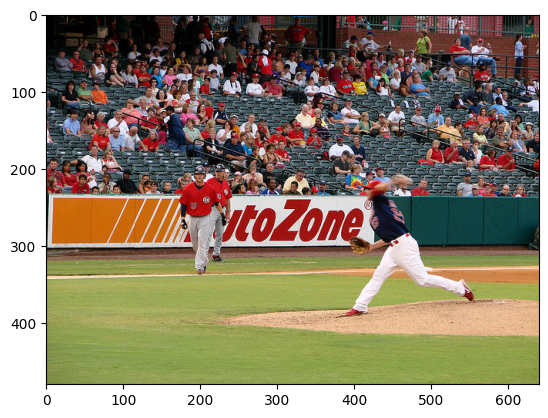

The image captures a thrilling moment in a baseball game, with a pitcher in the midst of throwing the ball. The pitcher, wearing a red jersey, is in the foreground, winding up to pitch the ball. The baseball is visible in the air, making its way towards the batter. 

In the background, there are several other players on the field, some holding baseball gloves, and others getting ready to make a play. There are also a few players wearing red jerseys, indicating that this is a match between two teams. 

The scene is filled with a variety of sports equipment, including multiple baseball gloves and the baseball itself. The players are spread across the field, with some closer to the foreground and others further away, emphasizing the action-packed nature of the game.


In [7]:
plt.imshow(image)
plt.show()
print(response)

In [5]:
model.generation_config = GenerationConfig.from_pretrained(checkpoint, trust_remote_code=True)
print(model.generation_config)

GenerationConfig {
  "chat_format": "chatml",
  "do_sample": true,
  "eos_token_id": 151643,
  "max_new_tokens": 512,
  "max_window_size": 6144,
  "pad_token_id": 151643,
  "top_k": 0,
  "top_p": 0.3,
  "transformers_version": "4.31.0",
  "trust_remote_code": true
}



In [8]:

input_tokens = tokenizer(prompt, return_tensors='pt', padding='longest')
input_ids = input_tokens.input_ids
attention_mask = input_tokens.attention_mask


Using pad_token, but it is not set yet.


ValueError: Asking to pad but the tokenizer does not have a padding token. Please select a token to use as `pad_token` `(tokenizer.pad_token = tokenizer.eos_token e.g.)` or add a new pad token via `tokenizer.add_special_tokens({'pad_token': '[PAD]'})`.

In [4]:
pred = model.generate(
    input_ids=input_ids.cuda(),
    attention_mask=attention_mask.cuda(),
    do_sample=False,
    num_beams=1,
    max_new_tokens=512,
    min_new_tokens=0,
    # length_penalty=0,
    # num_return_sequences=1,
    use_cache=True,
    pad_token_id=tokenizer.eod_id,
    eos_token_id=tokenizer.eod_id,
    # return_dict=True,
    # return_dict_in_generate=True,
    # output_hidden_states=True,
    # output_scores=True,
)


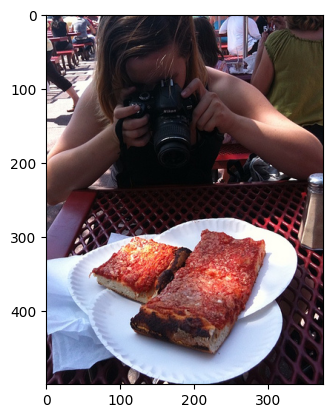

['Description: A woman is taking a picture of her food.']


In [5]:

outputs = [tokenizer.decode(_[input_ids.size(1):].cpu(),
skip_special_tokens=True).strip() for _ in pred]
plt.imshow(image)
plt.show()
print(outputs)